<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# 02 — Silero VAD on RAMC sessions

Run Silero VAD over every RAMC session WAV and save the per-frame
speech probabilities as `.npy` so the next notebooks can:

1. **Trim cut points to silence** — when an utterance ends mid-word
   in the diarization, nudge to the next nearby frame whose speech
   probability drops below threshold.
2. **Reject overlap zones** — boundaries where the trailing 200 ms of
   one speaker and the leading 200 ms of the next both show speech.

Frame layout matches the reference notebook in
`wavekat-turn/training/smart-turn-zh/notebooks/02-vad.ipynb`:
16 kHz audio, 512-sample window = **32 ms per frame**, one float32
per frame in `[0, 1]`. The structural-rule logic in notebook 03 only
needs to know `frame_idx → time_ms = frame_idx * 32`.

## Configure paths

Inputs: the same RAMC WAVs that notebook 01 listed. Outputs: one
`.npy` per session under the derived `smart-turn-zh-mining/vad_probs/`
directory. The notebook is resumable — sessions whose `.npy` already
exists are skipped, so this can be re-run incrementally on long
machines.

In [6]:
from pathlib import Path

WAV_DIR = Path("../../datasets/MagicData-RAMC/MDT2021S003/WAV").resolve()
OUT_DIR = Path("../../datasets/smart-turn-zh-mining/vad_probs").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE = 16_000
WINDOW_SIZE = 512                         # 32 ms per frame at 16 kHz
FRAME_MS = WINDOW_SIZE * 1000 // SAMPLE_RATE

print(f"WAV dir    : {WAV_DIR.name}")
print(f"Output dir : {OUT_DIR.parent.name}/{OUT_DIR.name}")
print(f"Frame size : {WINDOW_SIZE} samples ({FRAME_MS} ms @ {SAMPLE_RATE} Hz)")
print("✅ paths configured")

WAV dir    : WAV
Output dir : smart-turn-zh-mining/vad_probs
Frame size : 512 samples (32 ms @ 16000 Hz)
✅ paths configured


## Load Silero VAD

Same checkpoint the wavekat-turn reference notebook uses. MPS on Mac,
CPU otherwise — Silero is light enough that GPU is not required.

In [ ]:
import torch

model, _utils = torch.hub.load(
    repo_or_dir="snakers4/silero-vad",
    model="silero_vad",
    trust_repo=True,
)
# We don't use silero's bundled `read_audio` — it routes through
# torchaudio.load, which on torchaudio >= 2.9 requires torchcodec (and
# ffmpeg system bindings). soundfile (already in lab deps) reads RAMC's
# 16 kHz mono PCM-16 WAVs directly, with librosa as a resample fallback.

# Per timing on RAMC: CPU beats MPS (~2x) for this workload because the
# ops are tiny and per-call overhead dominates. Multi-thread also hurts
# (oversubscription on small RNN ops), so pin to a single thread.
device = torch.device("cpu")
torch.set_num_threads(1)
model = model.to(device).eval()
print(f"Silero VAD loaded on {device} (num_threads={torch.get_num_threads()})")
print("✅ VAD model ready")

## Discover sessions to process

Already-processed sessions (`.npy` exists) are skipped, so re-running
the cell after a partial run only does the remaining work.

In [12]:
wav_files = sorted(WAV_DIR.glob("*.wav"))
done = {p.stem for p in OUT_DIR.glob("*.npy")}
todo = [p for p in wav_files if p.stem not in done]

print(f"WAV files       : {len(wav_files)}")
print(f"Already done    : {len(done)}")
print(f"To process now  : {len(todo)}")
for p in todo[:3]:
    print(f"  next: {p.name}")
if len(todo) > 3:
    print(f"  ... and {len(todo) - 3} more")
print("✅ work list built")

WAV files       : 349
Already done    : 350
To process now  : 0
✅ work list built


## Run VAD — batched across sessions

Two stacked speedups vs the per-chunk Python loop you'd write naively:

1. **`model.audio_forward(wav, sr)`** — Silero's JIT model has a
   built-in whole-file entry that runs the per-chunk recurrence
   inside TorchScript. About **11× faster** than calling
   `model(chunk, sr)` from Python for every 512-sample frame
   (measured RTF 0.0032 vs 0.036 on RAMC).
2. **Batching `BATCH_SIZE` sessions** into one forward pass —
   `audio_forward` accepts a `(B, num_samples)` input, runs the
   recurrence in parallel across `B` sessions, and we slice the
   output back per-session. On a 3-session probe this took the RTF
   from 0.0032 down to **0.0015** — another ~2× over single-session.

Sessions in one batch are zero-padded to the longest member's length;
we trim each output back to the true frame count before saving so the
`.npy` files stay tightly aligned with each session's audio.

The atomic-write helper (`save_npy_atomic`) opens the temp file with
`open(..., "wb")` instead of letting `np.save` see a path-like —
`np.save` auto-appends `.npy` to anything that doesn't end in `.npy`,
which silently turned a previous `.npy.tmp` target into
`.npy.tmp.npy` and broke the rename step.

In [11]:
import numpy as np
import soundfile as sf
import torch.nn.functional as F
from tqdm.auto import tqdm

BATCH_SIZE = 4  # sessions processed in one forward pass


def read_wav_16k_mono(path) -> torch.Tensor:
    """Read a WAV as a 1-D float32 torch tensor at SAMPLE_RATE.

    Falls back to librosa for resample / channel-mix only when the
    source already isn't 16 kHz mono — RAMC's WAVs are, so the fast
    path runs for every session.
    """
    wav_np, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if wav_np.ndim > 1:
        wav_np = wav_np.mean(axis=1)
    if sr != SAMPLE_RATE:
        import librosa
        wav_np = librosa.resample(wav_np, orig_sr=sr, target_sr=SAMPLE_RATE)
    return torch.from_numpy(np.ascontiguousarray(wav_np))


def save_npy_atomic(out_path: Path, arr: np.ndarray) -> None:
    """Write `arr` to `out_path` via a sibling `.tmp` file + rename.

    `np.save` auto-appends `.npy` to any path-like that doesn't end in
    `.npy` — passing `Path('foo.npy.tmp')` writes to `foo.npy.tmp.npy`,
    breaking the rename. Open the file ourselves so the path is taken
    verbatim.
    """
    tmp_path = out_path.with_suffix(out_path.suffix + ".tmp")
    with open(tmp_path, "wb") as fh:
        np.save(fh, arr.astype(np.float32, copy=False))
    tmp_path.rename(out_path)


def num_chunks(n_samples: int) -> int:
    return (n_samples + WINDOW_SIZE - 1) // WINDOW_SIZE


with torch.inference_mode():
    pbar = tqdm(range(0, len(todo), BATCH_SIZE), desc="Batches")
    for batch_start in pbar:
        batch_paths = todo[batch_start : batch_start + BATCH_SIZE]
        wavs = [read_wav_16k_mono(p) for p in batch_paths]
        sample_lens = [len(w) for w in wavs]
        max_len = max(sample_lens)
        batch = torch.stack(
            [F.pad(w, (0, max_len - len(w))) for w in wavs]
        ).to(device)

        model.reset_states()
        probs_batch = model.audio_forward(batch, SAMPLE_RATE).cpu().numpy()
        # probs_batch shape: (B, ceil(max_len / WINDOW_SIZE))

        for wav_path, n_samples, probs in zip(batch_paths, sample_lens, probs_batch):
            trimmed = probs[: num_chunks(n_samples)]
            save_npy_atomic(OUT_DIR / f"{wav_path.stem}.npy", trimmed)

        pbar.set_postfix(last=batch_paths[-1].stem)

print(f"saved {len(todo)} new prob arrays to {OUT_DIR.name}/")
print("✅ VAD complete")

Batches:   0%|          | 0/88 [00:00<?, ?it/s]

saved 349 new prob arrays to vad_probs/
✅ VAD complete


## Sanity check vs RAMC diarization

If VAD and the RAMC transcripts disagree wildly on "how much of the
session is speech", something is wrong upstream — wrong WAV, wrong
sample rate, or a corrupt `.npy`. We don't expect them to match
exactly (RAMC's `[start, end]` ranges include speaker breath / short
pauses inside an utterance), but they should be in the same
ballpark.

RAMC `G00000000` rows are `[SONANT]` / `[MUSIC]` — non-speech — so we
exclude them when computing the diarization speech fraction.

In [15]:
import pandas as pd

UTTERANCES_PARQUET = Path("../../datasets/smart-turn-zh-mining/utterances.parquet").resolve()
utt = pd.read_parquet(UTTERANCES_PARQUET)
speech_utt = utt[utt["speaker_id"] != "G00000000"]

rows = []
for npy_path in sorted(OUT_DIR.glob("*.npy")):
    probs = np.load(npy_path)
    duration_s = len(probs) * WINDOW_SIZE / SAMPLE_RATE
    vad_active_s = float((probs > 0.5).sum()) * WINDOW_SIZE / SAMPLE_RATE
    diar = speech_utt[speech_utt["session_id"] == npy_path.stem]
    diar_speech_s = float(diar["duration_s"].sum())
    rows.append({
        "session_id":      npy_path.stem,
        "duration_s":      round(duration_s, 1),
        "vad_active_pct":  round(100 * vad_active_s / max(duration_s, 1e-6), 1),
        "diar_speech_pct": round(100 * diar_speech_s / max(duration_s, 1e-6), 1),
    })

summary = pd.DataFrame(rows)
summary["abs_diff_pct"] = (summary["vad_active_pct"] - summary["diar_speech_pct"]).abs()

print("per-session VAD vs diarization (first 10 sessions)")
print(summary.head(10).to_string(index=False))
print()
print("abs_diff_pct distribution across all sessions")
print(summary["abs_diff_pct"].describe().round(1).to_string())
outliers = summary[summary["abs_diff_pct"] > 20]
if len(outliers):
    print(f"\n⚠️  {len(outliers)} session(s) with > 20pp gap — inspect:")
    print(outliers.to_string(index=False))
print("✅ sanity check done")

per-session VAD vs diarization (first 10 sessions)
                session_id  duration_s  vad_active_pct  diar_speech_pct  abs_diff_pct
 CTS-CN-F2F-2019-11-11-198       843.4            70.0             81.7          11.7
 CTS-CN-F2F-2019-11-11-390       927.5            74.5             80.2           5.7
 CTS-CN-F2F-2019-11-11-423       855.2            79.9             89.2           9.3
 CTS-CN-F2F-2019-11-11-431       899.8            82.3             87.1           4.8
 CTS-CN-F2F-2019-11-11-716       904.5            70.0             76.4           6.4
 CTS-CN-F2F-2019-11-15-100      1864.0            78.1             83.1           5.0
CTS-CN-F2F-2019-11-15-1001      1921.2            83.3             84.1           0.8
CTS-CN-F2F-2019-11-15-1005      1953.7            77.2             84.2           7.0
 CTS-CN-F2F-2019-11-15-101      1924.4            61.1             73.6          12.5
CTS-CN-F2F-2019-11-15-1017      1935.1            74.1             84.1          10.0

ab

## Visualize one session

Pick the first session and plot:

1. Full-file overview — shows speech vs silence layout end-to-end.
2. First 60 s zoomed — eyeball-check that the per-frame curve looks
   like real speech activity, not noise.
3. Histogram — Silero typically gives a strong bimodal distribution
   (heavy mass near 0 and near 1). A muddy middle suggests the
   audio is noisy or off-rate.

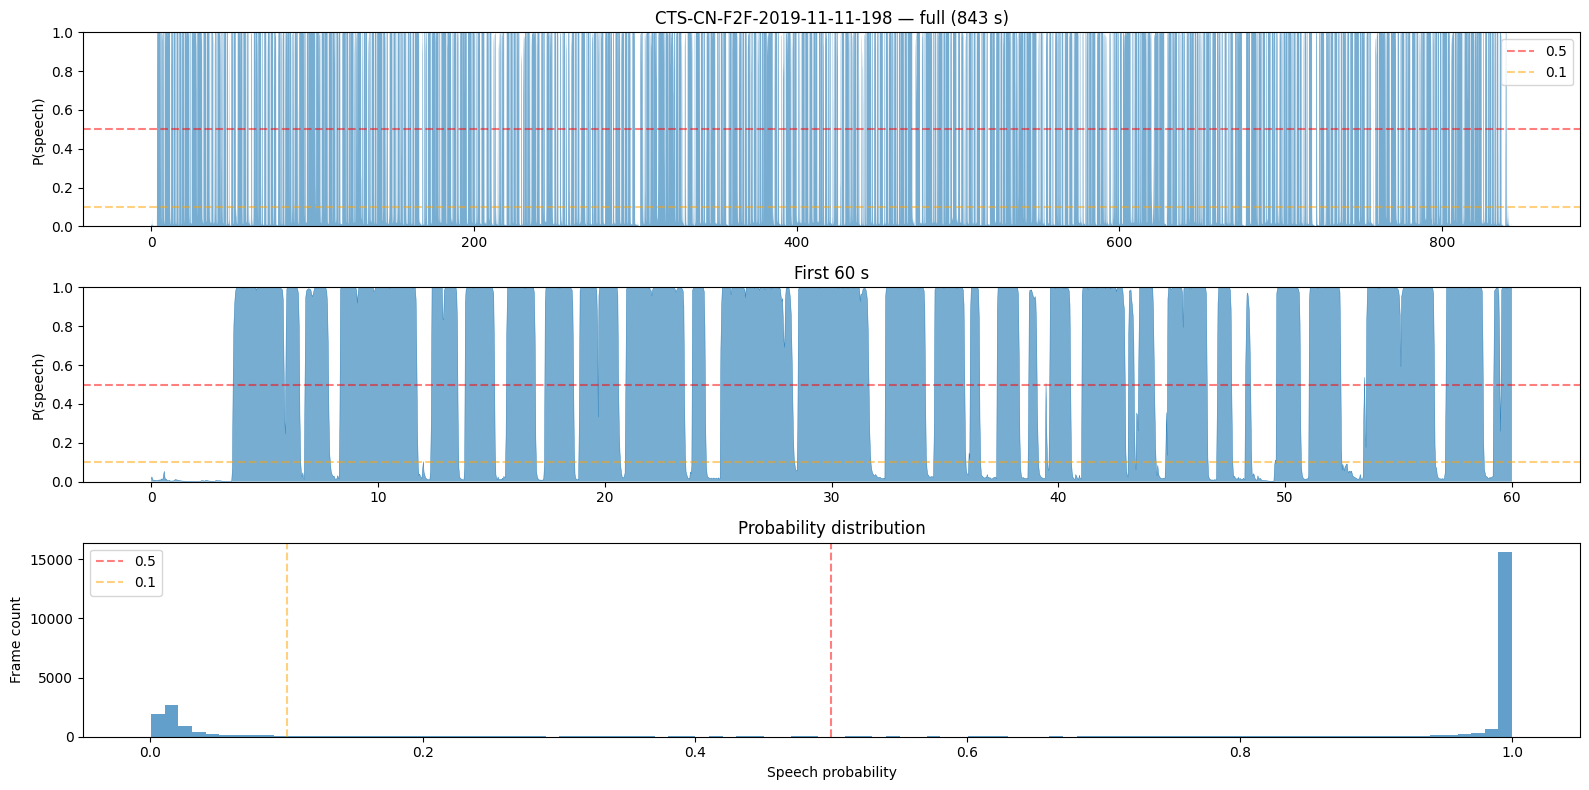

✅ preview rendered


In [16]:
import matplotlib.pyplot as plt

npy_files = sorted(OUT_DIR.glob("*.npy"))
probs = np.load(npy_files[0])
time_s = np.arange(len(probs)) * WINDOW_SIZE / SAMPLE_RATE

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=False)

axes[0].fill_between(time_s, probs, alpha=0.6)
axes[0].set_title(f"{npy_files[0].stem} — full ({time_s[-1]:.0f} s)")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.5, color="r", linestyle="--", alpha=0.5, label="0.5")
axes[0].axhline(y=0.1, color="orange", linestyle="--", alpha=0.5, label="0.1")
axes[0].legend(loc="upper right")

mask = time_s <= 60
axes[1].fill_between(time_s[mask], probs[mask], alpha=0.6)
axes[1].plot(time_s[mask], probs[mask], linewidth=0.3, color="C0")
axes[1].set_title("First 60 s")
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.5, color="r", linestyle="--", alpha=0.5)
axes[1].axhline(y=0.1, color="orange", linestyle="--", alpha=0.5)

axes[2].hist(probs, bins=100, edgecolor="none", alpha=0.7)
axes[2].set_xlabel("Speech probability")
axes[2].set_ylabel("Frame count")
axes[2].set_title("Probability distribution")
axes[2].axvline(x=0.5, color="r", linestyle="--", alpha=0.5, label="0.5")
axes[2].axvline(x=0.1, color="orange", linestyle="--", alpha=0.5, label="0.1")
axes[2].legend()

for ax in axes[:2]:
    ax.set_ylabel("P(speech)")

plt.tight_layout()
plt.show()
print("✅ preview rendered")

## Next

`vad_probs/{session_id}.npy` is now keyed on the same `session_id` as
`utterances.parquet`. Notebook 03 will:

- Pair adjacent rows in `utterances.parquet` to derive structural
  `end_of_turn` / `continuation` candidates.
- Use these VAD probs to nudge each cut point onto the nearest
  silence boundary, and to reject candidates whose RAMC boundary
  sits inside continuous speech.